# Apartat 1

La resposta impulsional del sistema $y[n]=x[n+1]+x[n-1]$ és $ \delta[n+1]-\delta[n-1]$

In [321]:
# Import de les llibreries
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, convolve2d

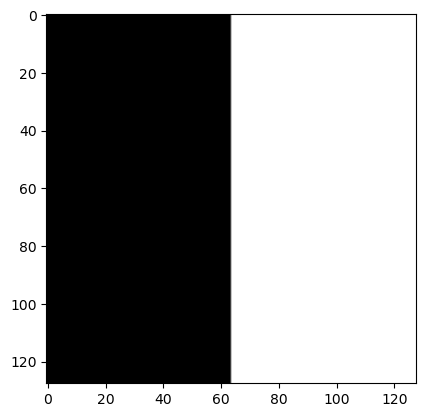

In [302]:

# Imatge de prova
N=128
X= np.zeros((N,N))
X[:, int(0.5*N):] = 1
plt.imshow(X, cmap='grey')


La matriu la hem inicialitzat a zero, que correspon al color negre. Amb la comanda seguent s'ha cambiat el valor de totes les columnes de la dreta a 1, que correspon al color blanc.

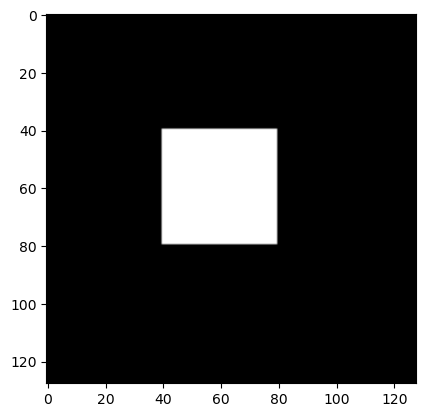

In [304]:
# Rectangle blanc a les coordenades [40,80]x,[40,80]y sobre fons negre
X[:,:]=0
X[40:80,40:80]=1
plt.imshow(X, cmap='grey')

S-ha cambiar el fons a negre i s-ha afegit un rectable blanc al centre.

# Apartat 2

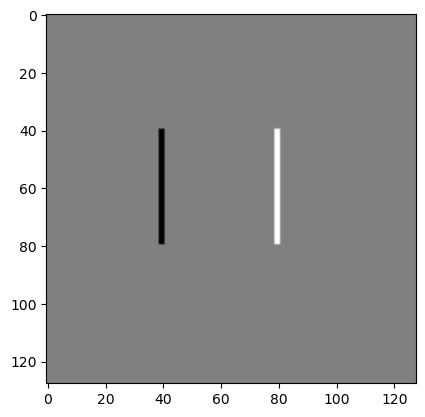

In [307]:
# Convolució de la imatge amb la resposta impulsional h
h = np.array([-1,0,1])
X_h=np.array([convolve(X_i, h, mode = "same") for X_i in X])
plt.imshow(X_h, cmap='grey')

Utilitzant la funció convolve() vista durant la pràctica, s-ha convolucionat el rectangle amb la funció h. El resultat són els laterals esquerra i dreta del rectangle.

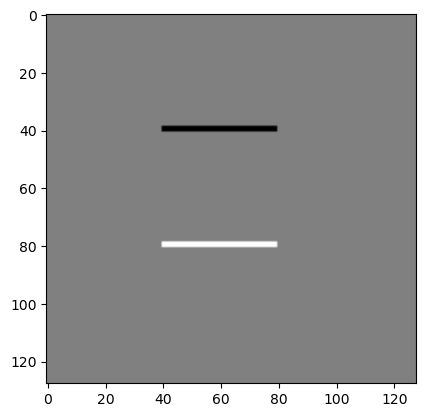

In [309]:
# Convolució de la imatge transposada amb la resposta impulsional h
X_t = X.T
X_v = np.array([convolve(X_i, h, mode = 'same') for X_i in X_t]).T
plt.imshow(X_v, cmap='grey')

Per obtenir els costats superior i inferior, s-ha transposat la matriu corresponent al rectangle, s-ha aplicat la convolució i s-ha tornat a transposar.

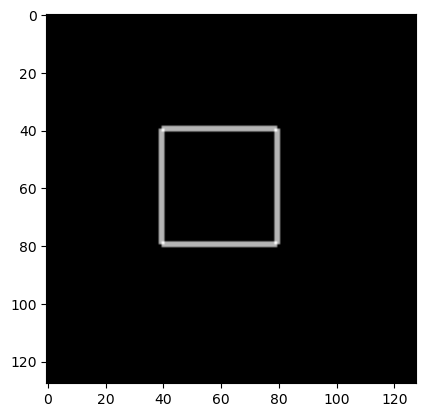

In [317]:
# Suma de les dues convolucions (distància geomètrica)
X_s = np.sqrt(X_h*X_h + X_v*X_v)
plt.imshow(X_s, cmap='grey')

Per ajuntar les dues convolucions s-utilitza la distància geomètrica.

# Apartat 3

EL filtre Sobel consisteix en aplicar per separats les matrius $$G_{x}=\begin{pmatrix}1 & 0 & -1  \\ 2 & 0 & -2 \\ 1 & 0 & -1\end{pmatrix}$$ $$G_{y}=\begin{pmatrix}1 & 2 & 1 \\ 0 & 0 & 0 \\ -1 & -2 & -1\end{pmatrix}$$ per després sumar-les amb la distància geomètrica.

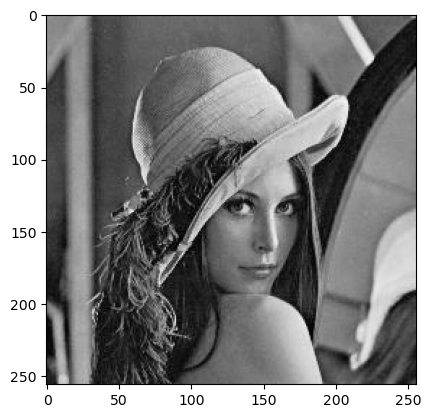

In [294]:
# Lectura de la imatge Lena.jpg
im = plt.imread('Lena.jpg')
im = im/np.max(im) 
plt.imshow(im,  cmap='gray') 


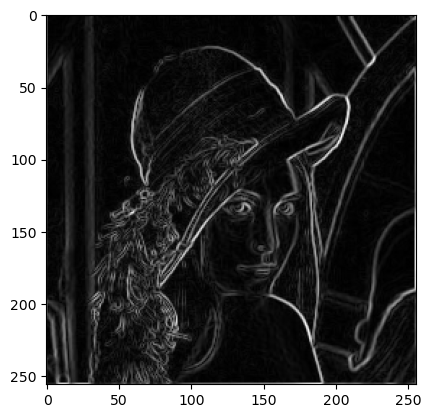

In [325]:
# Filtre de Lena.png mitjançant Sobel
G_x = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
G_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])
im_x=np.array(convolve2d(im, G_x, mode = "same"))
im_y=np.array(convolve2d(im, G_y, mode = "same"))
im_s = np.sqrt(im_x*im_x + im_y*im_y)
plt.imshow(im_s, cmap = 'gray')

Com es pot veure, la regió negre correspon a zones amb baix contrast de color, mentre que les zones clares corresponen a canvis bruscos de color.